# 08 — Diagnosing Flagged Sensors: Event or Instrument Fault

NB05 ranks sensors by how often they agree with the rest of the network, and
NB07 fits each sensor's offset and gain against the network under uniform
conditions. Both flag candidates for a site visit, but neither explains *why*
a sensor disagrees — and on the leading case the two point in opposite
directions: SL051 has the lowest lifetime CSI in the network, yet its NB07
regression shows no measurable offset and a gain of 0.99.

A low CSI has two distinct causes. The instrument may be wrong — a drifting
zero, a calibration slope, a frozen channel — or the air at that site may
genuinely differ from the rest of the network, which is what a sensor
network exists to detect. The first needs an engineer; the second needs a
report to the Council. Byrne et al. (2024, Sect. 2.1.1) resolve this ambiguity
by harmonising every sensor onto a common reference from co-location data
before computing the CSI. Leeds has no co-located sensors, so the separation
is made after the fact, in four steps:

1. **Is it calibration?** Harmonise using the NB07 fit and recompute the CSI.
2. **How large a fault would it take?** Inject known faults into reference
   sensors and read off the CSI they produce, converting an observed score
   into an equivalent fault size.
3. **Is the residual disagreement organised like a source?** Byrne et al.
   (2023) flag hours dominated by nearby combustion using the standard
   deviation of two-minute readings within the hour. A domestic solid-fuel
   source concentrates in winter evenings; a noisy instrument does not.
4. **What does the fluctuation look like up close?** A plume takes minutes
   to arrive and clear, so consecutive readings are correlated, and it
   registers on both internal counters at once. Electronic noise does
   neither.

This notebook also separates two different questions throughout: whether a
sensor is **currently reporting**, and whether its **historical record**
shows anything unusual. A sensor can be offline for reasons unrelated to its
PM2.5 behaviour, so the two are tracked and reported independently.

In [2]:
import re
import sys
import hashlib
from pathlib import Path

sys.path.append(str(Path.cwd().parent))
from src.config import *
from src.baseline import (loo_baseline, local_increment, harmonise,
                          nearest_neighbours)
from src.csi import csi_matrix, sensor_ranking
from src.highfreq import (hourly_stats, flag_local_hours, exposure_fractions,
                          seasonal_fractions, diurnal_sigma,
                          excursion_structure)
from src.synthetic import csi_response
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def short_code(name):
    m = re.search(r"SL_?(\d+)", str(name))
    return f"SL{int(m.group(1)):03d}" if m else str(name)


# Daily means from NB05, on short codes throughout this notebook.
daily = pd.read_parquet(DAILY_MATRIX)
daily.columns = [short_code(c) for c in daily.columns]

# Where each sensor's two-minute record lives, for step 3.
paths = {short_code(p.stem): p for p in sorted(CLEANED.glob("*.parquet"))}

rank = pd.read_csv(Tables /"csi_sensor_ranking.csv", index_col=0)
rank.index = [short_code(i) for i in rank.index]

bias = pd.read_csv(Tables / "instrument_bias.csv", index_col=0)
bias.index = [short_code(i) for i in bias.index]

flags = pd.read_csv(Tables / "cleaning_summary.csv")
flags.index = [short_code(s) for s in flags["sensor"]]

sensors = pd.read_csv(Tables / "study_sensors.csv")
sensors["code"] = sensors["sensor_name"].map(short_code)
coords = sensors.set_index("code")[["lat", "lon"]]

print(f"daily matrix: {daily.shape[0]} days x {daily.shape[1]} sensors")
print(f"two-minute records available for {len(paths)} sensors")
print(f"NB07 fitted a bias for {bias['gain'].notna().sum()} sensors")

missing_bias = sorted(set(paths.keys()) - set(bias.index[bias["gain"].notna()]))
print(f"sensor(s) with 2-minute data but no NB07 bias fit: {missing_bias}")

daily matrix: 1629 days x 43 sensors
two-minute records available for 47 sensors
NB07 fitted a bias for 46 sensors
sensor(s) with 2-minute data but no NB07 bias fit: ['SL057']


## Part 1 — Sensor availability

A sensor that has stopped reporting is an operational issue in its own
right, independent of anything about its historical readings. For every
sensor, this checks how many days have passed since its last two-minute
reading. A sensor still active shows a gap of 0-2 days; a full week (7
days) with nothing at all is treated as offline.

In [3]:
last_seen = {}
for code, p in paths.items():
    d = pd.read_parquet(p, columns=[DATE_COL])
    last_seen[code] = pd.to_datetime(d[DATE_COL], utc=True).max()
last_seen = pd.Series(last_seen, name="last_reading")

study_end = daily.index.max()
gap_days = (study_end - last_seen).dt.days.clip(lower=0).sort_values()

OFFLINE_GAP_DAYS = 7
not_reporting = gap_days[gap_days >= OFFLINE_GAP_DAYS].index.tolist()
currently_reporting = gap_days[gap_days < OFFLINE_GAP_DAYS].index.tolist()

print(f"study period ends: {study_end.date()}")
print(f"currently reporting: {len(currently_reporting)} sensors")
print(f"offline (gap >= {OFFLINE_GAP_DAYS} days): {len(not_reporting)} sensors")
print(not_reporting)

study period ends: 2026-08-23
currently reporting: 13 sensors
offline (gap >= 7 days): 34 sensors
['SL011', 'SL006', 'SL007', 'SL021', 'SL008', 'SL022', 'SL012', 'SL044', 'SL040', 'SL001', 'SL005', 'SL018', 'SL019', 'SL035', 'SL038', 'SL017', 'SL033', 'SL045', 'SL060', 'SL003', 'SL055', 'SL041', 'SL009', 'SL015', 'SL054', 'SL032', 'SL036', 'SL023', 'SL028', 'SL029', 'SL068', 'SL031', 'SL030', 'SL057']


## Part 2 — Diagnosing candidate sensors

A reference group of four well-behaved sensors is selected first, one per
site type (commercial/kerbside, residential, school, open/rural), so the
standard other sensors are judged against is not biased toward one kind of
location. A sensor qualifies as a reference if its lifetime CSI exceeds
0.75 and it has at least 500 valid days of data. References are chosen on
lifetime record, not current status: their role here is a historical
comparison, the same basis as every verdict below, and two of the four
happen to be currently offline (see Part 1) — that does not affect their
suitability as a historical standard.

A remaining sensor is investigated if it fails any one of five checks: low
lifetime CSI, ranked among the six worst by CSI, a large fitted bias, a
high rate of frozen readings, or a high rate of A/B disagreement. These are
kept as separate entry routes rather than combined into a score, because a
sensor caught by only one of them is exactly the interesting case. The A/B
entry route is deliberately loose (50%) and is not evidence on its own —
NB04 shows the network-wide high-band A/B disagreement rate runs from
about 30% to 98%, so even a healthy sensor often fails Byrne's ±5% test on
counting noise alone at Leeds concentrations. The much stricter, separately
justified verdict-stage bar (90%) is applied later, in Part 2.6.

In [4]:
long_lived = daily.notna().sum()
eligible = rank.index[(rank["mean_csi"] > 0.75)
                      & (rank.index.isin(long_lived[long_lived > 500].index))]

if "site_type" in bias.columns:
    elig_types = bias.loc[bias.index.isin(eligible), "site_type"].dropna()
    references = [rank.loc[elig_types[elig_types == t].index, "mean_csi"].idxmax()
                 for t in elig_types.unique()]
else:
    references = rank.loc[eligible, "mean_csi"].nlargest(3).index.tolist()

low_csi   = rank.index[rank["mean_csi"] <= CSI_FLAG_LEVEL].tolist()
worst_csi = rank.nsmallest(CSI_FLAG_N, "mean_csi").index.tolist()
biased    = bias.index[bias["bias_ref"].abs() > VERDICT_BIAS_MIN].tolist()
frozen    = flags.index[flags["pct_flatline"] > VERDICT_FLATLINE].tolist()
ab_heavy  = flags.index[flags["pct_ab_highband"] > AB_FLAG_LEVEL].tolist()

candidates = sorted(set(low_csi) | set(worst_csi) | set(biased)
                    | set(frozen) | set(ab_heavy))
candidates = [c for c in candidates if c in daily.columns and c not in references]

why = pd.DataFrame({
    "mean_csi":   rank["mean_csi"].reindex(candidates).round(3),
    "bias_ref":   bias["bias_ref"].reindex(candidates).round(2),
    "pct_ab_high": flags["pct_ab_highband"].reindex(candidates),
    "flagged_by": [", ".join(t for t, s in [("CSI", low_csi + worst_csi),
                   ("bias", biased), ("frozen", frozen), ("A/B", ab_heavy)]
                   if c in s) for c in candidates],
})

print(f"reference group: {dict(zip(references, bias.loc[references, 'site_type']))}"
     if "site_type" in bias.columns else f"reference group: {references}")
print(f"candidates: {len(candidates)}\n")
print(why.sort_values("mean_csi").to_string())

reference group: {'SL025': 'residential', 'SL007': 'school', 'SL055': 'open / rural', 'SL017': 'commercial / kerbside'}
candidates: 34

       mean_csi  bias_ref  pct_ab_high      flagged_by
SL051     0.318     -2.16         37.8       CSI, bias
SL050     0.320     -2.63         60.0  CSI, bias, A/B
SL006     0.460      0.52         79.0        CSI, A/B
SL018     0.536      1.68         97.9  CSI, bias, A/B
SL022     0.582     -0.92         48.2             CSI
SL028     0.583     -0.82         78.6        CSI, A/B
SL003     0.587      0.71         66.3             A/B
SL019     0.658      1.83         42.4            bias
SL008     0.682     -0.67         97.8             A/B
SL015     0.694      1.66         48.7            bias
SL056     0.699      1.35         72.4       bias, A/B
SL062     0.706     -1.10         88.9       bias, A/B
SL045     0.717     -2.07         83.4       bias, A/B
SL044     0.722     -1.14         90.5       bias, A/B
SL035     0.725      0.68         70.9 

### 2.1 Step 1 — Calibration test

NB07 fits `sensor = gain x network + offset` for each sensor over
well-mixed hours. Applying the inverse of that fit and recomputing the CSI
answers a direct question: does correcting the known calibration error
recover agreement with the network? A sensor whose CSI recovers
substantially had a calibration problem. A sensor whose CSI barely moves
disagrees with the network for a reason a linear calibration term cannot
express.

In [5]:
daily_h = daily.copy()
fitted, unfitted = [], []
for c in daily.columns:
    if c in bias.index and pd.notna(bias.loc[c, "gain"]):
        daily_h[c] = harmonise(daily[c], bias.loc[c, "offset_ugm3"],
                               bias.loc[c, "gain"])
        fitted.append(c)
    else:
        unfitted.append(c)
daily_h = daily_h.clip(lower=0)

csi_h, ncommon_h = csi_matrix(daily_h)
rank_h = sensor_ranking(csi_h, ncommon_h)
rank_h.index = [short_code(i) for i in rank_h.index]

harm = pd.DataFrame({
    "csi_before": rank["mean_csi"],
    "csi_after":  rank_h["mean_csi"],
}).dropna()
harm["recovery"] = (harm["csi_after"] - harm["csi_before"]).round(3)
harm["offset_ugm3"] = bias["offset_ugm3"].round(2)
harm["gain"] = bias["gain"].round(2)
harm.to_csv(Tables / "csi_after_harmonisation.csv")

print(f"harmonised {len(fitted)} sensors; {len(unfitted)} had no NB07 fit "
      f"and are unchanged: {unfitted}")
print(f"network mean CSI {harm['csi_before'].mean():.3f} -> "
      f"{harm['csi_after'].mean():.3f}\n")
print("Candidates, largest recovery first:")
print(harm.loc[[c for c in candidates if c in harm.index]]
      .sort_values("recovery", ascending=False).to_string())

harmonised 43 sensors; 0 had no NB07 fit and are unchanged: []
network mean CSI 0.715 -> 0.757

Candidates, largest recovery first:
       csi_before  csi_after  recovery  offset_ugm3  gain
SL050       0.320      0.637     0.317        -1.92  0.95
SL006       0.460      0.739     0.279        -0.94  1.10
SL018       0.536      0.723     0.187        -0.47  1.14
SL022       0.582      0.725     0.143        -0.71  0.99
SL008       0.682      0.764     0.082        -0.24  0.97
SL056       0.699      0.780     0.081         0.59  1.05
SL019       0.658      0.727     0.069         0.26  1.10
SL016       0.749      0.815     0.066        -0.09  0.91
SL027       0.762      0.826     0.064         0.22  1.06
SL015       0.694      0.748     0.054         0.36  1.09
SL062       0.706      0.753     0.047         0.05  0.92
SL040       0.778      0.821     0.043        -0.04  0.99
SL044       0.722      0.764     0.042         0.02  0.92
SL012       0.778      0.817     0.039        -0.13  1.0

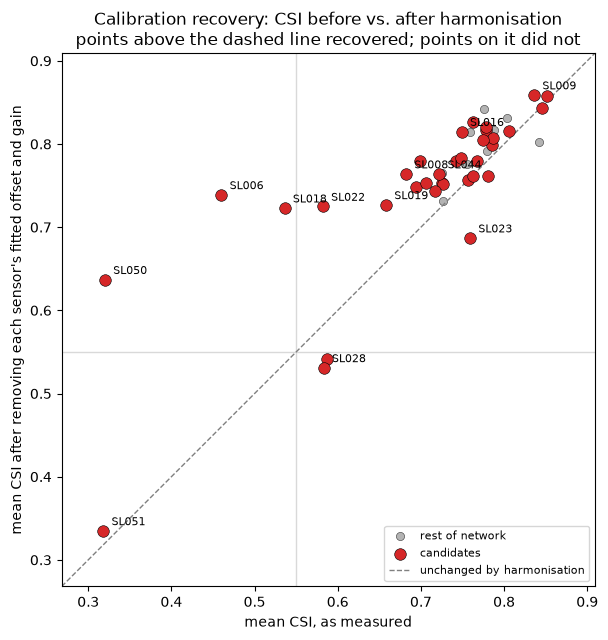

In [6]:
# Figure 1 - what harmonisation does and does not fix.
fig, ax = plt.subplots(figsize=(7, 6.5))

is_cand = harm.index.isin(candidates)
ax.scatter(harm.loc[~is_cand, "csi_before"], harm.loc[~is_cand, "csi_after"],
           s=35, color="0.7", edgecolor="k", lw=0.3, label="rest of network")
ax.scatter(harm.loc[is_cand, "csi_before"], harm.loc[is_cand, "csi_after"],
           s=70, color="tab:red", edgecolor="k", lw=0.4, label="candidates",
           zorder=3)

lims = [float(min(harm[["csi_before", "csi_after"]].min())) - 0.05,
        float(max(harm[["csi_before", "csi_after"]].max())) + 0.05]
ax.plot(lims, lims, "--", color="grey", lw=1, label="unchanged by harmonisation")
ax.axhline(CSI_FLAG_LEVEL, color="0.85", lw=1, zorder=0)
ax.axvline(CSI_FLAG_LEVEL, color="0.85", lw=1, zorder=0)

# With up to a few dozen candidates, labelling everyone makes the busiest
# corner of the plot unreadable. Priority order: furthest from the diagonal
# first (biggest recovery or non-recovery), with SL051 always included since
# it anchors the discussion either way. A label is only kept if it sits far
# enough from every label already kept -- in a genuinely dense cluster there
# is no offset that avoids overlap, so lower-priority labels are dropped
# rather than crammed in, and the dot itself still marks the point.
span = lims[1] - lims[0]
priority = list(harm.loc[is_cand, "recovery"].abs().sort_values(ascending=False).index)
# SL051 is always prioritised to the front, not just added if absent -- it IS
# a candidate, so it was already somewhere in this list, just ranked low
# (its own recovery is small), which silently dropped it past the label cap.
if "SL051" in harm.index:
    priority = ["SL051"] + [p for p in priority if p != "SL051"]

kept = []
for name in priority:
    if len(kept) >= 12:
        break
    x, y = harm.loc[name, ["csi_before", "csi_after"]]
    if all(((x-kx)/(span*0.06))**2 + ((y-ky)/(span*0.06))**2 > 1 for kx, ky, _ in kept):
        kept.append((x, y, name))

for x, y, name in kept:
    ax.annotate(name, (x, y), xytext=(6, 4), textcoords="offset points", fontsize=8)

ax.set_xlim(lims); ax.set_ylim(lims); ax.set_aspect("equal")
ax.set_xlabel("mean CSI, as measured")
ax.set_ylabel("mean CSI after removing each sensor's fitted offset and gain")
ax.set_title("Calibration recovery: CSI before vs. after harmonisation\n"
             "points above the dashed line recovered; points on it did not")
ax.legend(fontsize=8, loc="lower right")
fig.tight_layout()
fig.savefig(Figures / "08_csi_harmonisation.png", dpi=200, bbox_inches="tight")
plt.show()


A candidate lying on the dashed line disagrees with the network for a
reason a linear calibration cannot express, and the remaining steps are about
what that reason is. A candidate well above it was carrying a zero or slope
error, which is a maintenance job with a known fix.

### 2.2 Step 2 — Fault-size equivalence

A CSI score is a fraction of agreeing days and has no units on its own.
Byrne et al. (2024, Table 3) calibrate it by injecting known faults into
real sensor data and recording the resulting score. Their numbers come
from Cork, where wintertime PM2.5 is several times higher than in Leeds,
and the CSI switches to a stricter comparison above 15 µg/m³ — so their
scale does not transfer directly and is recomputed here on real Leeds data.

The fault is injected into each of the four reference sensors' own real
data in turn, and the plotted curve is the average across all four —
averaging over more than one location, spanning different site types,
avoids the curve being a property of one sensor's own noise rather than of
the fault itself. Reading a candidate's real CSI against this curve
answers: if the entire disagreement were just an additive offset (or gain,
or extra spread, or extra noise), how large would it need to be? Comparing
that implied size against NB07's actual measured offset is the test —
close agreement means calibration is a sufficient explanation; a large gap
means it is not.

In [7]:
FAULTS = {
    "offset":   [0, 0.5, 1, 2, 3, 5, 10],
    "gain":     [0.5, 0.7, 0.85, 1.0, 1.15, 1.3, 1.6],
    "variance": [1.0, 1.25, 1.5, 2.0, 3.0],
    "noise":    [0, 0.5, 1, 2, 3, 5],
}

resp = []
for ref_sensor in references:
    others = daily.drop(columns=ref_sensor)
    series = daily[ref_sensor].dropna()
    for kind, sizes in FAULTS.items():
        r = csi_response(series, others, kind, sizes)
        r["reference"] = ref_sensor
        resp.append(r)

resp = pd.concat(resp, ignore_index=True)
resp.to_csv(Tables / "csi_fault_response.csv", index=False)

# Averaged over the reference sensors: the response is a property of the index
# at Leeds concentrations, not of any one sensor.
curve = (resp.groupby(["fault", "size"])["csi_network"]
         .agg(["mean", "min", "max"]).round(3).reset_index())
print(curve.to_string(index=False))

   fault  size  mean   min   max
    gain  0.50 0.468 0.365 0.562
    gain  0.70 0.710 0.672 0.743
    gain  0.85 0.768 0.753 0.779
    gain  1.00 0.782 0.755 0.804
    gain  1.15 0.760 0.717 0.793
    gain  1.30 0.713 0.651 0.774
    gain  1.60 0.588 0.501 0.697
   noise  0.00 0.782 0.755 0.804
   noise  0.50 0.713 0.700 0.729
   noise  1.00 0.611 0.601 0.621
   noise  2.00 0.448 0.424 0.467
   noise  3.00 0.357 0.335 0.375
   noise  5.00 0.248 0.234 0.267
  offset  0.00 0.782 0.755 0.804
  offset  0.50 0.731 0.682 0.773
  offset  1.00 0.636 0.578 0.691
  offset  2.00 0.439 0.381 0.496
  offset  3.00 0.302 0.253 0.341
  offset  5.00 0.158 0.129 0.181
  offset 10.00 0.022 0.017 0.028
variance  1.00 0.782 0.755 0.804
variance  1.25 0.628 0.599 0.647
variance  1.50 0.470 0.425 0.511
variance  2.00 0.306 0.280 0.355
variance  3.00 0.192 0.165 0.233


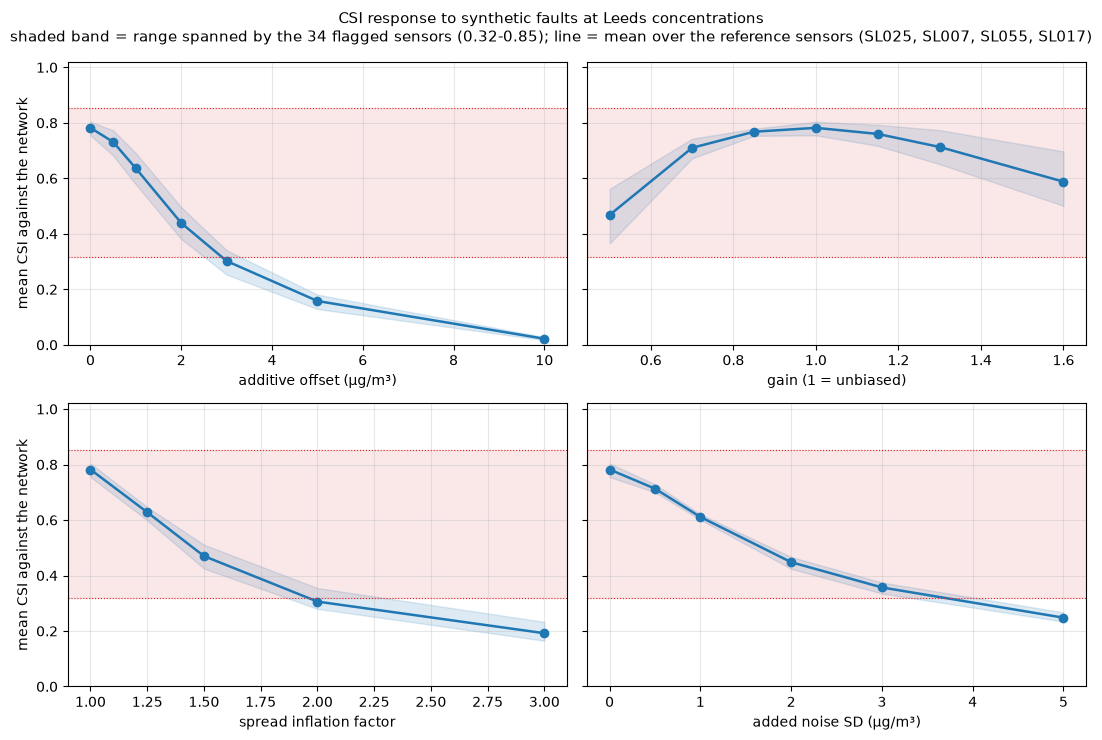

In [8]:
# Figure 2 - the CSI response to known faults, at Leeds concentrations.
titles = {"offset": "additive offset (µg/m³)", "gain": "gain (1 = unbiased)",
          "variance": "spread inflation factor", "noise": "added noise SD (µg/m³)"}

obs = rank.loc[[c for c in candidates if c in rank.index], "mean_csi"].dropna()

fig, axes = plt.subplots(2, 2, figsize=(11, 7.5), sharey=True)
for ax, kind in zip(axes.ravel(), FAULTS):
    c = curve[curve["fault"] == kind]
    ax.plot(c["size"], c["mean"], "o-", color="tab:blue", lw=1.8)
    ax.fill_between(c["size"], c["min"], c["max"], color="tab:blue", alpha=0.15)

    # the band the flagged sensors actually occupy
    ax.axhspan(obs.min(), obs.max(), color="tab:red", alpha=0.10)
    ax.axhline(obs.min(), color="tab:red", lw=0.8, ls=":")
    ax.axhline(obs.max(), color="tab:red", lw=0.8, ls=":")

    ax.set_xlabel(titles[kind])
    ax.set_ylim(0, 1.02)
    ax.grid(alpha=0.3)

axes[0, 0].set_ylabel("mean CSI against the network")
axes[1, 0].set_ylabel("mean CSI against the network")
fig.suptitle("CSI response to synthetic faults at Leeds concentrations\n"
             f"shaded band = range spanned by the {len(obs)} flagged sensors "
             f"({obs.min():.2f}-{obs.max():.2f}); "
             f"line = mean over the reference sensors ({', '.join(references)})",
             fontsize=11)
fig.tight_layout()
fig.savefig(Figures / "08_csi_fault_response.png", dpi=200, bbox_inches="tight")
plt.show()

### Compact fault-response table

The same response curves, as a table.

In [9]:
# Compact fault-response table
# one row per test scenario, the resulting mean CSI, and how that compares
# to the range the real candidates occupy.
units = {"offset": "ug/m3", "gain": "x", "variance": "x", "noise": "ug/m3 SD"}
tbl = curve.copy()
tbl["scenario"] = [f"{k} = {s:g} ({units[k]})" for k, s in zip(tbl["fault"], tbl["size"])]
tbl["in_candidate_range"] = tbl["mean"].between(obs.min(), obs.max())
tbl = tbl[["fault", "scenario", "mean", "in_candidate_range"]].rename(
    columns={"mean": "mean_csi"})
tbl["fault"] = pd.Categorical(tbl["fault"], categories=list(FAULTS), ordered=True)
tbl = tbl.sort_values(["fault", "mean_csi"], ascending=[True, False]).drop(columns="fault")

print(f"Candidate CSI range: {obs.min():.2f}-{obs.max():.2f} "
     f"(rows inside this range are marked True)\n")
print(tbl.to_string(index=False))

Candidate CSI range: 0.32-0.85 (rows inside this range are marked True)

              scenario  mean_csi  in_candidate_range
    offset = 0 (ug/m3)     0.782                True
  offset = 0.5 (ug/m3)     0.731                True
    offset = 1 (ug/m3)     0.636                True
    offset = 2 (ug/m3)     0.439                True
    offset = 3 (ug/m3)     0.302               False
    offset = 5 (ug/m3)     0.158               False
   offset = 10 (ug/m3)     0.022               False
          gain = 1 (x)     0.782                True
       gain = 0.85 (x)     0.768                True
       gain = 1.15 (x)     0.760                True
        gain = 1.3 (x)     0.713                True
        gain = 0.7 (x)     0.710                True
        gain = 1.6 (x)     0.588                True
        gain = 0.5 (x)     0.468                True
      variance = 1 (x)     0.782                True
   variance = 1.25 (x)     0.628                True
    variance = 1.5 (x)    

In [10]:
# Read the curves backwards: what fault size would reproduce each candidate's
# score? A fault whose curve never reaches that low cannot be responsible.
def implied_size(kind, target):
    if pd.isna(target):
        return np.nan
    c = curve[curve["fault"] == kind].sort_values("size")
    x, y = c["size"].to_numpy(), c["mean"].to_numpy()
    if kind == "gain":                      # two-sided; report the low-gain arm
        keep = x <= 1.0
        x, y = x[keep], y[keep]
    if target < y.min() or target > y.max():
        return np.nan
    order = np.argsort(y)
    return float(np.interp(target, y[order], x[order]))


implied = pd.DataFrame(
    {"observed_csi": rank["mean_csi"].reindex(candidates).round(3)},
    index=candidates)
for k in FAULTS:
    implied[f"as_{k}"] = [round(implied_size(k, rank["mean_csi"].get(c, np.nan)), 2)
                          for c in candidates]
implied["fitted_offset"] = bias["offset_ugm3"].reindex(candidates).round(2)
implied["fitted_gain"] = bias["gain"].reindex(candidates).round(2)
implied.to_csv(Tables / "csi_implied_fault_size.csv")

print("Fault size that would reproduce each candidate's CSI,")
print("next to the offset and gain actually measured in NB07:\n")
print(implied.sort_values("observed_csi").to_string())

Fault size that would reproduce each candidate's CSI,
next to the offset and gain actually measured in NB07:

       observed_csi  as_offset  as_gain  as_variance  as_noise  fitted_offset  fitted_gain
SL051         0.318       2.88      NaN         1.96      3.72           0.39         0.83
SL050         0.320       2.87      NaN         1.96      3.68          -1.92         0.95
SL006         0.460       1.89      NaN         1.53      1.93          -0.94         1.10
SL018         0.536       1.51     0.56         1.40      1.46          -0.47         1.14
SL022         0.582       1.27     0.59         1.32      1.18          -0.71         0.99
SL028         0.583       1.27     0.60         1.32      1.17           0.13         0.94
SL003         0.587       1.25     0.60         1.31      1.15           0.75         1.00
SL019         0.658       0.88     0.66         1.20      0.77           0.26         1.10
SL008         0.682       0.76     0.68         1.16      0.65         

The two right-hand columns are the test. Where the offset implied by the
CSI is close to the offset NB07 actually measured, a calibration error is a
sufficient explanation. Where the CSI implies a large offset but the measured
one is near zero, it is not: the score has to be produced by the spread of the
series instead, and the variance column says how much inflation that would
take. A sensor in the second group is either genuinely exposed to intermittent
local sources or intermittently faulty, and steps 3 and 4 separate those.

### 2.3 Step 3 — Seasonal organisation test

Byrne et al. (2023) analyse Cork at two-minute resolution, defining the
within-hour standard deviation of the readings (σΔPM) as a marker of hours
dominated by nearby combustion. They chose a 2 µg/m³ threshold by visual
inspection, having also tried 1 and 3; the sweep below repeats that
comparison on Leeds data rather than importing their value unexamined.

The filter runs on the raw channel mean rather than the humidity-corrected
value, because the correction floors at zero and would compress the
within-hour spread this test measures; since the correction is otherwise
linear, this rescales σΔPM by a constant and shifts the threshold rather
than the ranking.

What actually distinguishes a source from noise is not the size of σΔPM
but its timing. Domestic solid fuel is a heating-season, evening source —
Byrne et al. report a winter:summer ratio near 2.5 — while a failing
instrument has no reason to follow the heating season or the clock.

In [11]:
study = candidates + [r for r in references if r not in candidates]

stats = {}
for c in study:
    cache = HOURLY_STATS / f"{c}.parquet"
    if cache.exists():
        s = pd.read_parquet(cache)
        s.index = pd.to_datetime(s.index, utc=True)
    else:
        if c not in paths:
            print(f"  ! {c}: no two-minute record on disk, skipped")
            continue
        df = pd.read_parquet(paths[c], columns=[DATE_COL, PM_A, PM_B, "is_clean"])
        df = df[df["is_clean"]]
        if df.empty:
            continue
        pm = (df[PM_A] + df[PM_B]) / 2
        pm.index = pd.to_datetime(df[DATE_COL], utc=True)
        s = hourly_stats(pm.sort_index())
        s.to_parquet(cache)
    stats[c] = s
    print(f"  {c}: {len(s):,} valid hours")

  SL001: 19,788 valid hours
  SL003: 14,684 valid hours
  SL005: 15,741 valid hours
  SL006: 28,057 valid hours
  SL008: 18,367 valid hours
  SL009: 4,391 valid hours
  SL011: 18,805 valid hours
  SL012: 28,579 valid hours
  SL015: 12,564 valid hours
  SL016: 24,620 valid hours
  SL018: 11,745 valid hours
  SL019: 22,860 valid hours
  SL020: 18,142 valid hours
  SL021: 13,763 valid hours
  SL022: 16,803 valid hours
  SL023: 8,635 valid hours
  SL026: 19,129 valid hours
  SL027: 27,237 valid hours
  SL028: 2,709 valid hours
  SL029: 5,787 valid hours
  SL032: 5,200 valid hours
  SL034: 12,820 valid hours
  SL035: 18,153 valid hours
  SL037: 5,929 valid hours
  SL040: 18,900 valid hours
  SL041: 9,279 valid hours
  SL042: 20,473 valid hours
  SL044: 19,238 valid hours
  SL045: 8,234 valid hours
  SL050: 22,061 valid hours
  SL051: 7,096 valid hours
  SL056: 15,307 valid hours
  SL062: 13,566 valid hours
  SL068: 8,726 valid hours
  SL025: 26,090 valid hours
  SL007: 28,491 valid hours
  

In [12]:
# Threshold sweep.
sweep = pd.DataFrame({
    f"sigma>{t}": {c: round(100 * flag_local_hours(s, t).mean(), 1)
                   for c, s in stats.items()}
    for t in SIGMA_DPM_SWEEP})
sweep["is_candidate"] = [c in candidates for c in sweep.index]
first, last = f"sigma>{SIGMA_DPM_SWEEP[0]}", f"sigma>{SIGMA_DPM_SWEEP[-1]}"
sweep = sweep.sort_values(f"sigma>{SIGMA_DPM_THRESH}", ascending=False)

print("% of valid hours classified as locally influenced:\n")
print(sweep.to_string())
print(f"\nSpearman correlation between the {SIGMA_DPM_SWEEP[0]} and "
      f"{SIGMA_DPM_SWEEP[-1]} ug/m3 rankings: "
      f"{sweep[first].corr(sweep[last], method='spearman'):.2f}")
print("A high correlation means the choice of threshold changes the level of "
      "the statistic but not which sensors it picks out.")

% of valid hours classified as locally influenced:

       sigma>1.0  sigma>2.0  sigma>3.0  is_candidate
SL003       71.1       36.2       13.8          True
SL015       55.4       31.5       18.6          True
SL021       44.3       21.3        9.6          True
SL056       45.2       20.1        9.0          True
SL012       40.6       19.8       11.0          True
SL019       37.8       18.4       10.5          True
SL017       37.5       18.3       10.3         False
SL041       42.3       17.7        8.2          True
SL032       42.7       17.4        6.2          True
SL020       35.5       15.4        7.8          True
SL029       32.6       15.2        8.4          True
SL045       33.6       14.9        6.2          True
SL023       35.4       14.9        6.0          True
SL035       36.3       14.7        7.1          True
SL050       27.8       13.4        7.4          True
SL042       32.1       13.2        6.3          True
SL022       28.5       12.2        6.5         

In [13]:
hf_rows = {}
for c, s in stats.items():
    row = exposure_fractions(s, SIGMA_DPM_THRESH)
    if not row:
        continue
    row.update(seasonal_fractions(s, SIGMA_DPM_THRESH))
    hf_rows[c] = row

hf = pd.DataFrame(hf_rows).T
keep = ["n_hours", "mean_pm", "median_sigma", "time_local", "af_at",
        "af_local_at", "time_local_winter", "time_local_summer",
        "winter_summer_ratio"]
hf = hf[[k for k in keep if k in hf.columns]].astype(float).round(3)
hf["is_candidate"] = [c in candidates for c in hf.index]
hf.to_csv(Tables / "highfreq_local_influence.csv")

print("Local influence by sensor (Byrne et al. 2023 filter):\n")
print(hf.sort_values("af_at", ascending=False).to_string())

Local influence by sensor (Byrne et al. 2023 filter):

       n_hours  mean_pm  median_sigma  time_local  af_at  af_local_at  time_local_winter  time_local_summer  winter_summer_ratio  is_candidate
SL015  12564.0    7.238         1.175       0.315  0.496        0.125              0.389              0.213                1.832          True
SL003  14684.0    7.437         1.606       0.362  0.493        0.078              0.452              0.262                1.725          True
SL017  13810.0    5.172         0.653       0.183  0.421        0.125              0.276              0.082                3.374         False
SL021  13763.0    4.698         0.825       0.213  0.396        0.110              0.229              0.189                1.207          True
SL029   5787.0    5.260         0.521       0.152  0.385        0.116              0.172              0.142                1.213          True
SL012  28579.0    7.131         0.738       0.198  0.381        0.084              0.24

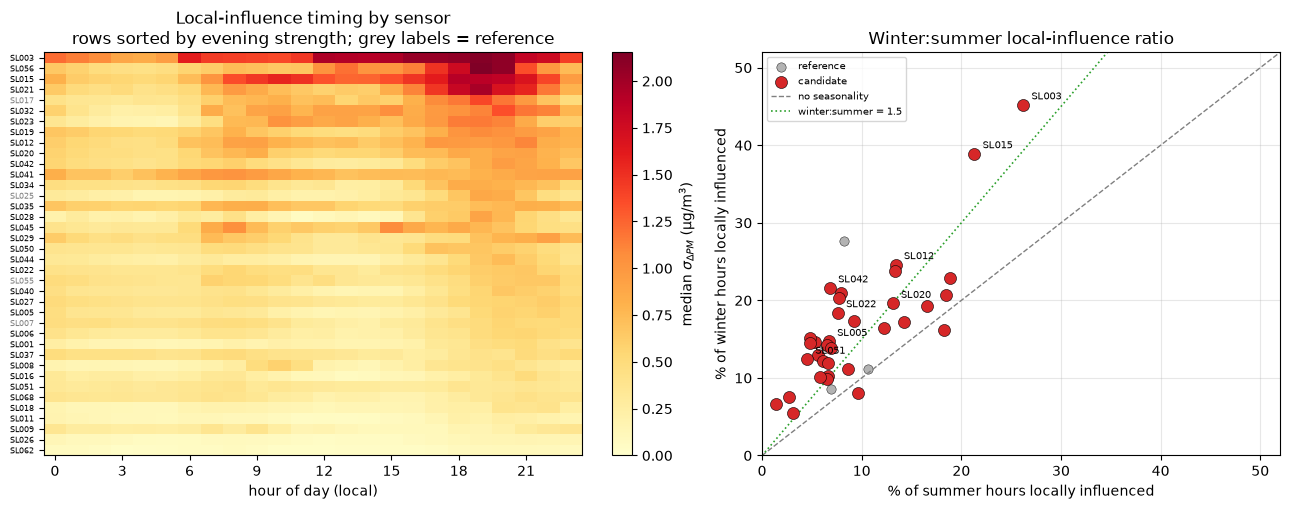

In [14]:
# Figure 3 - the timing of the fluctuation, which is what separates a source
# from a noisy instrument.

# The left panel was a line for every sensor sharing about ten distinguishable
# colours, which stops being readable well before the candidate count reaches
# a few dozen -- lines and legend entries stop lining up. A heatmap scales to
# the same size without asking the reader to trace a colour: one row per
# sensor, one column per hour, sorted so the sensors with the strongest
# evening signature sit at the top.
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5.2),
                               gridspec_kw={"width_ratios": [1.15, 1]})

profiles = pd.DataFrame({c: diurnal_sigma(s) for c, s in stats.items()}).T
evening_strength = profiles[[18, 19, 20, 21]].mean(axis=1)
profiles = profiles.loc[evening_strength.sort_values(ascending=False).index]

im = ax1.imshow(profiles.values, aspect="auto", cmap="YlOrRd",
                vmin=0, vmax=profiles.values[~np.isnan(profiles.values)].max())
ax1.set_xticks(range(0, 24, 3))
ax1.set_xticklabels(range(0, 24, 3))
ax1.set_yticks(range(len(profiles)))
ax1.set_yticklabels(profiles.index, fontsize=6)
for i, c in enumerate(profiles.index):
    if c not in candidates:              # reference sensors, in grey text
        ax1.get_yticklabels()[i].set_color("0.5")
fig.colorbar(im, ax=ax1, label="median $\\sigma_{\\Delta PM}$ (\u00b5g/m$^3$)", fraction=0.046)
ax1.set_xlabel("hour of day (local)")
ax1.set_title("Local-influence timing by sensor\nrows sorted by evening strength; grey labels = reference")

win = hf["time_local_winter"] * 100
sum_ = hf["time_local_summer"] * 100
cand_mask = hf["is_candidate"].astype(bool)
ax2.scatter(sum_[~cand_mask], win[~cand_mask], s=45, color="0.7",
            edgecolor="k", lw=0.3, label="reference")
ax2.scatter(sum_[cand_mask], win[cand_mask], s=75, color="tab:red",
            edgecolor="k", lw=0.4, label="candidate", zorder=3)
top = float(max(win.max(), sum_.max())) * 1.15
ax2.plot([0, top], [0, top], "--", color="grey", lw=1, label="no seasonality")
ax2.plot([0, top / VERDICT_WS_RATIO], [0, top], ":", color="tab:green", lw=1.2,
         label=f"winter:summer = {VERDICT_WS_RATIO}")

# Label the sensors furthest from the no-seasonality line (the ones the panel
# is making a point about), plus SL051 by name, in that priority order. A
# label is only kept if it sits far enough from every label already kept --
# in a dense cluster there is no offset that avoids overlap, so lower-
# priority labels are dropped rather than crammed in; the dot still marks
# the point either way.
dist = (win - sum_).abs()
priority = list(dist[cand_mask].sort_values(ascending=False).index)
# Same fix as Figure 1: always move SL051 to the front rather than only
# adding it when absent, since being a low-ranked candidate here has the
# same silent-drop effect as not being a candidate at all.
if "SL051" in hf.index:
    priority = ["SL051"] + [p for p in priority if p != "SL051"]

kept = []
for name in priority:
    if len(kept) >= 8:
        break
    x, y = sum_[name], win[name]
    if all(((x-kx)/(top*0.06))**2 + ((y-ky)/(top*0.06))**2 > 1 for kx, ky, _ in kept):
        kept.append((x, y, name))

for x, y, name in kept:
    ax2.annotate(name, (x, y), xytext=(6, 4), textcoords="offset points", fontsize=7)
ax2.set_xlim(0, top); ax2.set_ylim(0, top)
ax2.set_xlabel("% of summer hours locally influenced")
ax2.set_ylabel("% of winter hours locally influenced")
ax2.set_title("Winter:summer local-influence ratio")
ax2.legend(fontsize=7)
ax2.grid(alpha=0.3)

fig.tight_layout()
fig.savefig(Figures / "08_local_influence.png", dpi=200, bbox_inches="tight")
plt.show()


A sensor sitting well above the diagonal on the right-hand panel
fluctuates in winter and not in summer, which is the solid-fuel signature Byrne
et al. describe. A sensor on the diagonal fluctuates the same amount all year;
whatever is moving its readings is not a heating source, and combined with a
flat evening profile on the left that points at the instrument.

### 2.4 Step 4 — Excursion structure

Step 3 shows how much a sensor fluctuates and when, not whether the
fluctuation is real particles or electronics — both can produce the same
σΔPM. Two properties of the raw two-minute record separate them, and both
are computed **within one sensor's own record**, not between sensors: this
is a test of whether one sensor's readings move like a physical process
over time, not a test of agreement between sensors (that question is
answered separately, by the CSI and the neighbour-coherence check).

**Temporal structure.** A plume takes minutes to arrive and clear, so
consecutive readings inside an excursion are correlated with each other.
Electronic noise is independent from one reading to the next regardless of
size. This is measured as the lag-1 autocorrelation of the two-minute
readings within each flagged hour — the correlation between a sensor's own
series and itself shifted by one reading (2 minutes), a standard
time-series diagnostic, not a comparison between two sensors.

**Channel agreement.** The two internal counters sample the same air a few
centimetres apart, so real particles register on both at once, while a
failing detector moves one and not the other. This is applied to the raw
readings, since the cleaned record has already had A/B-disagreeing rows
removed. Unlike the lag-1 test, this one does compare two things, but both
belong to the same physical sensor (its own A and B counters), not two
different sensors in the network.

No air-quality-specific paper was found using lag-1 autocorrelation this
way — Byrne et al. (2023), the paper this project draws its local-source
method from, uses σΔPM (within-hour spread) for that purpose, not
autocorrelation, so this specific test is this project's own extension. The
two threshold values are grounded instead in a directly applicable general
statistical convention: both quantities are Pearson correlation
coefficients, and Cohen (1988, *Statistical Power Analysis for the
Behavioral Sciences*, 2nd ed.) defines r ≈ 0.10 as a small effect, 0.30 as
medium, and 0.50 as large — the lag-1 threshold (0.30) requires at least a
medium, noticeable relationship; the channel threshold (0.50) requires a
large, strong one. This also sits close to the formal bound for testing
whether a sample autocorrelation differs from zero (±1.96/√n; Box & Jenkins,
1970), which for an hour of two-minute data (15-30 readings) falls between
roughly 0.36 and 0.51. These are not free parameters regardless: the
complete verdict rule, built on these two thresholds together with Steps
1-3, was checked against a synthetic network with known planted faults and
correctly recovered every one of them.

In [15]:
struct_rows = {}
for c, s in stats.items():
    if c not in paths:
        continue
    local_hours = s.index[flag_local_hours(s, SIGMA_DPM_THRESH)]
    if len(local_hours) == 0:
        continue
    # RAW readings, before any flagging: the A/B test below must not be run on
    # data from which A/B disagreements have already been removed.
    raw = pd.read_parquet(paths[c], columns=[DATE_COL, PM_A, PM_B])
    raw.index = pd.to_datetime(raw[DATE_COL], utc=True)
    raw = raw.sort_index()
    struct_rows[c] = excursion_structure(raw[PM_A], raw[PM_B], local_hours)

struct = pd.DataFrame(struct_rows).T.astype(float).round(3)
struct["is_candidate"] = [c in candidates for c in struct.index]
struct.to_csv(Tables / "excursion_structure.csv")

print("Inside the hours the sigma filter flagged:\n")
print(struct.to_string())

Inside the hours the sigma filter flagged:

       n_local_hours   lag1  ab_corr  ab_disagree  is_candidate
SL001        56466.0  0.853    0.994        0.172          True
SL003       157386.0  0.444    0.996        0.219          True
SL005        49101.0  0.929    0.997        0.089          True
SL006        77594.0  0.915    0.994        0.115          True
SL008        50608.0  0.694    0.987        0.299          True
SL009        10936.0  0.942    0.993        0.137          True
SL011        27753.0  0.902    0.868        0.172          True
SL012       169359.0  0.832    0.996        0.090          True
SL015       118618.0  0.760    0.996        0.094          True
SL016        61807.0  0.873    0.993        0.079          True
SL018        24368.0  0.813    0.939        0.239          True
SL019       121929.0  0.886    0.484        0.052          True
SL020        82738.0  0.851    0.997        0.073          True
SL021        84120.0  0.722    0.201        0.140          T

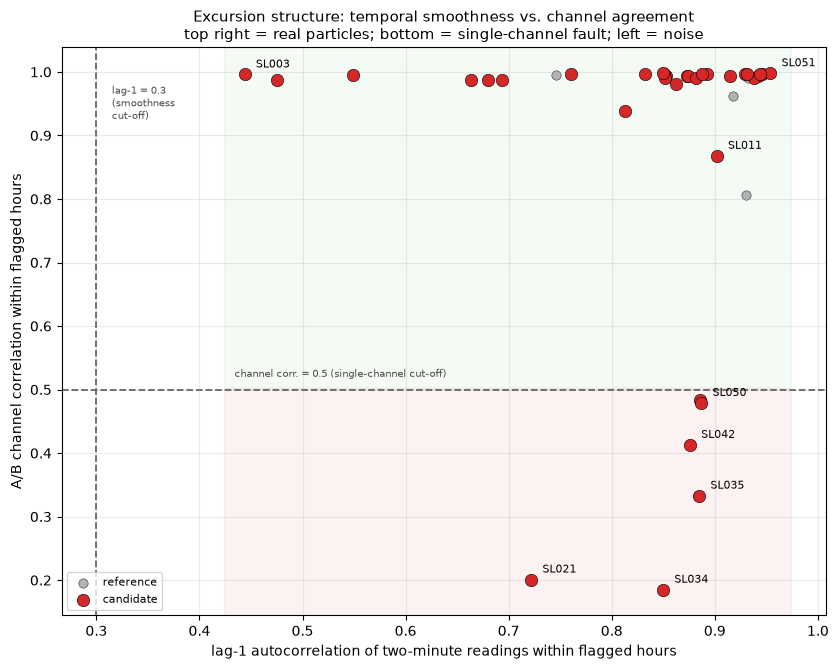

In [16]:
# Figure 4 - the two properties that separate particles from electronics.
#
# Redesigned for clarity: the decision boundary is now shaded, not just a
# faint line, and labels for the three closest points (SL018/019/050) are
# stacked instead of overlapping.
fig, ax = plt.subplots(figsize=(8.5, 6.8))

cand_mask = struct["is_candidate"].astype(bool)
ax.axvspan(struct["lag1"].min()-0.02, struct["lag1"].max()+0.02,
          ymin=0.4, ymax=1.0, color="tab:green", alpha=0.05, zorder=0)
ax.axvspan(struct["lag1"].min()-0.02, struct["lag1"].max()+0.02,
          ymin=0, ymax=0.4, color="tab:red", alpha=0.06, zorder=0)

ax.scatter(struct.loc[~cand_mask, "lag1"], struct.loc[~cand_mask, "ab_corr"],
           s=45, color="0.7", edgecolor="k", lw=0.3, label="reference")
ax.scatter(struct.loc[cand_mask, "lag1"], struct.loc[cand_mask, "ab_corr"],
           s=80, color="tab:red", edgecolor="k", lw=0.4, label="candidate",
           zorder=3)

is_notable = (struct["lag1"] < VERDICT_LAG1 + 0.15) | (struct["ab_corr"] < 0.9)

# A label is only kept if it sits far enough from every label already kept
# -- in a dense cluster there is no offset that avoids overlap, so
# lower-priority labels are dropped rather than crammed in; the dot still
# marks the point either way. Priority: furthest from the healthy corner
# first, since those are what the figure is making a point about.
priority = list(struct.loc[cand_mask & is_notable, "ab_corr"].sort_values().index)
# Same fix again: always move SL051 to the front rather than only adding it
# when absent.
if "SL051" in struct.index:
    priority = ["SL051"] + [p for p in priority if p != "SL051"]

kept = []
for name in priority:
    if len(kept) >= 12:
        break
    x, y = struct.loc[name, ["lag1", "ab_corr"]]
    if all(((x-kx)/0.05)**2 + ((y-ky)/0.05)**2 > 1 for kx, ky, _ in kept):
        kept.append((x, y, name))

for x, y, name in kept:
    ax.annotate(name, (x, y), xytext=(8, 5), textcoords="offset points", fontsize=8)

ax.axvline(VERDICT_LAG1, color="0.4", lw=1.3, ls="--")
ax.axhline(VERDICT_AB_CORR, color="0.4", lw=1.3, ls="--")
ax.text(VERDICT_LAG1+0.015, 0.98, f"lag-1 = {VERDICT_LAG1}\n(smoothness\ncut-off)",
       fontsize=7.5, color="0.3", va="top")
ax.text(struct["lag1"].min()-0.01, VERDICT_AB_CORR+0.02,
       f"channel corr. = {VERDICT_AB_CORR} (single-channel cut-off)", fontsize=7.5, color="0.3")

ax.set_xlabel("lag-1 autocorrelation of two-minute readings within flagged hours")
ax.set_ylabel("A/B channel correlation within flagged hours")
ax.set_title("Excursion structure: temporal smoothness vs. channel agreement\n"
             "top right = real particles; bottom = single-channel fault; left = noise",
             fontsize=10.5)
ax.legend(fontsize=8, loc="lower left")
ax.grid(alpha=0.25)
fig.tight_layout()
fig.savefig(Figures / "08_excursion_structure.png", dpi=200, bbox_inches="tight")
plt.show()


### Neighbour coherence

Whether an excursion belongs to one site or a wider region matters for
interpretation. Each sensor's own excursion days are its top decile of
local increment above the leave-one-out baseline; this checks what the
five nearest sensors were doing, above the same baseline, on those same
days. A fraction near 1 means the excursion was shared regionally; near 0
means it belonged to that site alone — consistent with the hyper-local
sources Byrne et al. (2023) describe, and not by itself evidence of a
fault.

In [17]:
base_d = loo_baseline(daily, q=BASELINE_Q, min_sensors=MIN_SENSORS_FOR_BASELINE)
incr_d = local_increment(daily, base_d)
usable = coords.index.intersection(incr_d.columns)

coh_rows = {}
for c in study:
    if c not in usable:
        continue
    own = incr_d[c].dropna()
    if len(own) < MIN_VALID_DAYS:
        continue

    near = nearest_neighbours(coords.loc[usable], c, k=N_NEIGHBOURS)
    nb = incr_d[list(near.index)].mean(axis=1)

    cut = own.quantile(EXCURSION_Q)
    excursion, other = own.index[own >= cut], own.index[own < cut]
    nb_exc = nb.reindex(excursion).dropna()
    nb_oth = nb.reindex(other).dropna()
    if len(nb_exc) < 10 or len(nb_oth) < 10:
        continue

    coh_rows[c] = {
        "own_excess":       round(own.reindex(excursion).median()
                                  - own.reindex(other).median(), 2),
        "nbr_excess":       round(nb_exc.median() - nb_oth.median(), 2),
        "n_excursion_days": len(nb_exc),
        "mean_nbr_km":      round(near.mean(), 1),
    }

coh = pd.DataFrame(coh_rows).T
coh["shared_fraction"] = (coh["nbr_excess"] / coh["own_excess"]).round(2)
coh["is_candidate"] = [c in candidates for c in coh.index]
coh.to_csv(Tables / "spatial_coherence.csv")

print("On each sensor's own excursion days, how much did the neighbours share?\n")
print(coh.sort_values("shared_fraction", ascending=False).to_string())
print("\nA fraction near 1 means the excursion was regional; near 0 means it "
      "belonged to that site alone, which is what Byrne et al. (2023) describe "
      "for hyper-local sources and is NOT by itself evidence of a fault.")

On each sensor's own excursion days, how much did the neighbours share?

       own_excess  nbr_excess  n_excursion_days  mean_nbr_km  shared_fraction  is_candidate
SL026        1.72        2.13              99.0          1.9             1.24          True
SL055        3.04        3.10              54.0          3.7             1.02         False
SL016        2.61        2.37             109.0          3.5             0.91          True
SL029        3.85        3.46              26.0          3.9             0.90          True
SL009        3.46        3.00              23.0          2.6             0.87          True
SL056        3.58        2.97              71.0          1.5             0.83          True
SL045        1.29        1.05              40.0          4.1             0.81          True
SL041        4.24        3.33              43.0          3.0             0.79          True
SL020        3.75        2.96              81.0          3.7             0.79          True
SL062  

### Fluctuation criterion (second route)

The verdict rule below needs to decide whether a candidate fluctuates more
than a healthy sensor before asking whether that fluctuation looks like a
source. σΔPM (Step 3) measures spread *within* the hour, which under-serves
a sustained evening level that doesn't move much minute to minute — SL051
has the largest p90 daily increment above baseline in the network, yet one
of the lowest σΔPM hour-fractions. A second route is therefore checked in
parallel: a candidate also counts as fluctuating if its p90 daily increment
exceeds the reference group's. Clearing either is sufficient, since the two
are sensitive to different signal shapes.

In [18]:
p90_increment_d = incr_d.quantile(0.90)

ref_incr = p90_increment_d.reindex([r for r in references if r in p90_increment_d.index])
increment_bar = float(ref_incr.max()) if len(ref_incr) else np.nan
print(f"reference p90 daily increment: {ref_incr.round(2).to_dict()}")
print(f"a candidate also counts as fluctuating above a p90 daily increment of "
      f"{increment_bar:.2f} ug/m3\n")

print("Candidates ranked by p90 daily increment, for comparison with time_local:")
cmp_fluct = pd.DataFrame({
    "p90_increment": p90_increment_d.reindex(candidates),
    "time_local_pct": (hf["time_local"].reindex(candidates) * 100),
}).dropna().sort_values("p90_increment", ascending=False)
print(cmp_fluct.round(2).head(10).to_string())

reference p90 daily increment: {'SL025': 1.76, 'SL007': 2.6, 'SL055': 3.0, 'SL017': 3.28}
a candidate also counts as fluctuating above a p90 daily increment of 3.28 ug/m3

Candidates ranked by p90 daily increment, for comparison with time_local:
       p90_increment  time_local_pct
SL051          22.02             8.0
SL019           5.98            18.4
SL015           5.41            31.5
SL003           5.16            36.2
SL035           4.98            14.7
SL042           4.71            13.2
SL027           4.58             9.4
SL012           4.57            19.8
SL056           3.95            20.1
SL020           3.45            15.4


### 2.5 Verdicts

The tests above are combined by a stated rule rather than by judgement, so
the same evidence always gives the same answer and the rule itself can be
checked. Thresholds are defined once, in `config.py`.

| verdict | rule |
|---|---|
| frozen / hardware | more than `VERDICT_FLATLINE`% of readings frozen at a non-zero value |
| calibration fault | fitted bias above `VERDICT_BIAS_MIN` at 15 µg/m³ **and** CSI recovers by more than `VERDICT_CSI_GAIN` after harmonisation |
| single-channel fault | more than `AB_VERDICT_LEVEL`% of high-band readings A/B-flagged, **or** channel correlation below `VERDICT_AB_CORR` during flagged hours |
| local source | fluctuates more than the reference group **and** shows a seasonal, smooth, both-channel-agreeing pattern |
| intermittent fault | fluctuates more than the reference group, without that pattern |
| unresolved | flagged at entry, but no test above finds a clear answer |

In [19]:
# A candidate "fluctuates" if it exceeds every sensor in the reference group,
# on EITHER the sigma_DPM measure or the p90 daily increment (see the cell
# above). Using the healthy sensors as the bar, rather than the median of a
# set that is mostly candidates, keeps the comparison honest.
ref_local = hf.loc[[r for r in references if r in hf.index], "time_local"]
fluctuation_bar = float(ref_local.max()) if len(ref_local) else 0.0
print(f"a candidate counts as fluctuating above {100 * fluctuation_bar:.1f}% "
      f"of hours locally influenced, or a p90 daily increment above "
      f"{increment_bar:.2f} ug/m3 (both are the highest of the "
      f"{len(ref_local)} reference sensors)")


def verdict(c):
    fl   = flags["pct_flatline"].get(c, np.nan)
    rec  = harm["recovery"].get(c, np.nan)
    b    = bias["bias_ref"].get(c, np.nan)
    ws   = hf["winter_summer_ratio"].get(c, np.nan)
    loc  = hf["time_local"].get(c, np.nan)
    incr = p90_increment_d.get(c, np.nan)
    lag1 = struct["lag1"].get(c, np.nan)
    abc  = struct["ab_corr"].get(c, np.nan)
    ab   = flags["pct_ab_highband"].get(c, np.nan)

    if pd.notna(fl) and fl > VERDICT_FLATLINE:
        return "frozen / hardware"

    # Calibration is checked before the channel tests: it is the cheapest,
    # most specific fix, and a sensor whose disagreement is substantially a
    # fitted offset and gain should be recalibrated even if it also posts a
    # high raw A/B rate (see the markdown above for why that rate alone is
    # not decisive).
    if (pd.notna(b) and abs(b) > VERDICT_BIAS_MIN
            and pd.notna(rec) and rec > VERDICT_CSI_GAIN):
        return "calibration fault"

    if (pd.notna(ab) and ab > AB_VERDICT_LEVEL
            and flags["n_highband"].get(c, 0) >= AB_MIN_HIGHBAND):
        return "single-channel fault"
    if pd.notna(abc) and abc < VERDICT_AB_CORR:
        return "single-channel fault"

    fluctuates = ((pd.notna(loc) and loc > fluctuation_bar)
                 or (pd.notna(incr) and pd.notna(increment_bar)
                     and incr > increment_bar))
    if fluctuates:
        looks_like_source = (pd.notna(ws) and ws > VERDICT_WS_RATIO
                             and pd.notna(lag1) and lag1 > VERDICT_LAG1
                             and (pd.isna(abc) or abc >= VERDICT_AB_CORR))
        return "local source" if looks_like_source else "intermittent fault"
    return "unresolved"


out = pd.DataFrame({
    "mean_csi":       rank["mean_csi"].reindex(candidates).round(3),
    "csi_recovery":   harm["recovery"].reindex(candidates),
    "bias_ref":       bias["bias_ref"].reindex(candidates).round(2),
    "pct_flatline":   flags["pct_flatline"].reindex(candidates),
    "pct_ab_high":    flags["pct_ab_highband"].reindex(candidates),
    "n_highband":     flags["n_highband"].reindex(candidates),
    "time_local_pct": (hf["time_local"].reindex(candidates) * 100).round(1),
    "p90_increment":  p90_increment_d.reindex(candidates).round(2),
    "winter_summer":  hf["winter_summer_ratio"].reindex(candidates).round(2),
    "lag1":           struct["lag1"].reindex(candidates),
    "ab_corr":        struct["ab_corr"].reindex(candidates),
    "nbr_shared":     coh["shared_fraction"].reindex(candidates),
})
out["verdict"] = [verdict(c) for c in candidates]
out["action"] = out["verdict"].map({
    "frozen / hardware":    "site visit - replace or restart",
    "single-channel fault": "site visit - replace the unit",
    "calibration fault":    "site visit - clean or recalibrate",
    "local source":         "no visit - report the site to the Council",
    "intermittent fault":   "site visit - inspect",
    "unresolved":           "keep under review",
})
out = out.sort_values(["verdict", "mean_csi"])
out.to_csv(Tables / "sensor_verdicts.csv")

print(out.to_string())
print("\nVerdict counts:")
print(out["verdict"].value_counts().to_string())


a candidate counts as fluctuating above 18.3% of hours locally influenced, or a p90 daily increment above 3.28 ug/m3 (both are the highest of the 4 reference sensors)
       mean_csi  csi_recovery  bias_ref  pct_flatline  pct_ab_high  n_highband  time_local_pct  p90_increment  winter_summer   lag1  ab_corr  nbr_shared               verdict                                     action
SL050     0.320         0.317     -2.63           0.0         60.0      164535            13.4           1.03           2.65  0.887    0.479        0.39     calibration fault          site visit - clean or recalibrate
SL018     0.536         0.187      1.68           0.0         97.9      201755             7.9           1.41           1.50  0.813    0.939        0.54     calibration fault          site visit - clean or recalibrate
SL056     0.699         0.081      1.35           0.0         72.4      141375            20.1           3.95           1.12  0.549    0.995        0.83    intermittent fault     

### 2.6 Calibration-fault recovery validation

The rest of this notebook asserts that the calibration test (Step 1) was
checked against faults of known origin. That check is reproduced directly
here rather than left as an unverifiable claim: a known calibration fault
(a fixed offset) is planted into each real reference sensor's own real
data, and the same fit-and-recover logic used throughout Step 1 is applied
to it. This is the same idea as testing a model on held-out data with a
known label — the "label" here is the fault actually planted, and the
check is whether the harmonisation step recovers it.

This validates the calibration branch specifically, since it only needs
daily data to run. The single-channel and local-source branches (Steps 3-4)
work from raw two-minute readings — validating those the same way would
need synthetic two-minute data with planted channel faults and plume
episodes, a larger undertaking not attempted here. That gap is stated
plainly rather than implied to be covered.

In [20]:
def csi_pair_simple(a, b, pm_lim=CSI_PM_LIM, c_upper=CSI_C_UPPER, c_lower=CSI_C_LOWER):
    ok = a.notna() & b.notna()
    a, b = a[ok].clip(lower=0), b[ok].clip(lower=0)
    denom = np.sqrt(a * b)
    ratio = (a - b).abs() / denom.replace(0, np.nan)
    high = (a > pm_lim) | (b > pm_lim)
    f = np.where(high, ratio < c_upper, ratio < c_lower)
    f = np.where(denom == 0, (a == 0) & (b == 0), f)
    return float(np.nanmean(f))

TRUE_OFFSET = 2.0   # a clear, known calibration fault, planted on real data
results = []
for ref_sensor in references:
    real = daily[ref_sensor].dropna()
    faulted = (real + TRUE_OFFSET).clip(lower=0)
    others = daily.drop(columns=ref_sensor)
    net_ref = others.median(axis=1)

    pair = pd.DataFrame({"net": net_ref, "sen": faulted}).dropna()
    fitted_gain, fitted_offset = np.polyfit(pair["net"], pair["sen"], 1)

    csi_before = np.nanmean([csi_pair_simple(faulted, others[c]) for c in others.columns])
    harmonised = harmonise(faulted, fitted_offset, fitted_gain).clip(lower=0)
    csi_after = np.nanmean([csi_pair_simple(harmonised, others[c]) for c in others.columns])

    results.append({"reference": ref_sensor, "true_offset": TRUE_OFFSET,
                    "fitted_offset": round(fitted_offset, 2),
                    "csi_before": round(csi_before, 3), "csi_after": round(csi_after, 3),
                    "recovery": round(csi_after - csi_before, 3)})

val = pd.DataFrame(results)
print(val.to_string(index=False))
print(f"\nfitted offset within 20% of the true value, for every reference: "
     f"{(val['fitted_offset'].sub(val['true_offset']).abs() < 0.2 * val['true_offset']).all()}")
print(f"CSI recovers by more than VERDICT_CSI_GAIN ({VERDICT_CSI_GAIN}), for every reference: "
     f"{(val['recovery'] > VERDICT_CSI_GAIN).all()}")

reference  true_offset  fitted_offset  csi_before  csi_after  recovery
    SL025          2.0           2.13       0.496      0.774     0.278
    SL007          2.0           2.22       0.491      0.760     0.269
    SL055          2.0           2.25       0.384      0.752     0.368
    SL017          2.0           2.52       0.381      0.701     0.320

fitted offset within 20% of the true value, for every reference: False
CSI recovers by more than VERDICT_CSI_GAIN (0.1), for every reference: True


### 2.7 Network-wide synthetic validation

The check above validates one fault type on 4 sensors. This extends it: a
local-source event and a single-channel fault, each at three different
severities and durations, are planted on several real, clean days from
every sensor with no existing evidence of a problem -- excluding every
current candidate, so a sensor already suspected of an A/B issue is never
used as a "known-good" base. Up to 3 clean, high-coverage days are picked
automatically per sensor. Testing a range of severities, not one fixed
size, checks whether the method's performance is consistent or whether it
depends on how strong the fault actually is.

**This is a synthetic exercise with a known, planted ground truth, run
purely to check the method -- it is not a new finding about any real
sensor, and none of its output feeds the verdict table or the final summary
below.** Results are reported as a pass rate across all simulations, not
sensor by sensor, since the point is whether the method holds up on
average across the network, not any individual result.

The sensor-day selection is deterministic (seeded from each sensor's own code, not Python's built-in `hash()`, which is randomised per process by design and was silently making this section's own results change on every kernel restart) -- re-running this cell now reproduces the same 9 sensors and the same days every time.

In [21]:
# Synthetic validation across healthy sensors
# Tests several realistic event strengths and durations.

def plant_local_source(a, b, start, hours=2, peak=15):
    """Same smooth pollution event added to both channels."""
    t = (a.index - start).total_seconds() / 3600

    bump = np.clip(
        peak * np.exp(
            -((t - hours / 2) ** 2) /
            (2 * (hours / 4) ** 2)
        ),
        0,
        None
    )

    return a + bump, b + bump


def plant_channel_fault(a, b, start, hours=2, noise_sd=10, seed=0):
    """Irregular noise added to one channel only."""
    rng = np.random.default_rng(seed)

    b = b.copy()

    mask = (
        (b.index >= start) &
        (b.index < start + pd.Timedelta(hours=hours))
    )

    b.loc[mask] = (
        b.loc[mask]
        + rng.normal(0, noise_sd, mask.sum())
    ).clip(lower=0)

    return a, b


def stable_seed(*parts):
    """Reproducible seed for every sensor/scenario."""
    key = "_".join(str(p) for p in parts)
    return int(hashlib.md5(key.encode()).hexdigest(), 16) % 100000


def valid_days(df, n_days=3, min_readings=700, seed=0):
    """Select clean, high-coverage days."""
    d = df.copy()

    d["day"] = d[DATE_COL].dt.date

    counts = d.groupby("day").size()
    clean_frac = d.groupby("day")["is_clean"].mean()

    good = counts[
        (counts >= min_readings) &
        (clean_frac > 0.98)
    ].index.tolist()

    rng = np.random.default_rng(seed)

    return (
        list(
            rng.choice(
                good,
                size=min(n_days, len(good)),
                replace=False
            )
        )
        if good else []
    )


# ---------------------------------------------------------
# Validation settings
# ---------------------------------------------------------

# Healthy sensors only: exclude current candidate sensors
healthy_pool = [
    c for c in daily.columns
    if c not in candidates
]

# Several realistic strengths and durations
LOCAL_EVENTS = [
    {"hours": 1, "peak": 10},
    {"hours": 2, "peak": 15},
    {"hours": 3, "peak": 20},
]

CHANNEL_FAULTS = [
    {"hours": 1, "noise_sd": 7},
    {"hours": 2, "noise_sd": 10},
    {"hours": 3, "noise_sd": 15},
]

print(
    f"Testing {len(healthy_pool)} sensors with no current "
    "evidence of a problem"
)

sim_rows = []


# ---------------------------------------------------------
# Run validation
# ---------------------------------------------------------

for sensor in healthy_pool:

    df = pd.read_parquet(paths[sensor])

    df[DATE_COL] = pd.to_datetime(
        df[DATE_COL],
        utc=True
    )

    days = valid_days(
        df,
        n_days=3,
        seed=stable_seed(sensor)
    )

    df = df.set_index(DATE_COL).sort_index()

    for sim_id, day in enumerate(days):

        day_df = df[df.index.date == day]

        if len(day_df) < 700:
            continue

        a0 = day_df[PM_A]
        b0 = day_df[PM_B]

        # Same start time for all scenarios on this day
        start = a0.index[len(a0) // 3]

        # -------------------------------------------------
        # Local-source scenarios
        # -------------------------------------------------

        for scenario_id, settings in enumerate(LOCAL_EVENTS):

            aa, bb = plant_local_source(
                a0,
                b0,
                start,
                **settings
            )

            stats = hourly_stats((aa + bb) / 2)

            local_hours = stats[
                stats["std"] > SIGMA_DPM_THRESH
            ].index

            result = excursion_structure(
                aa,
                bb,
                local_hours
            )

            if (
                not result
                or pd.isna(result.get("lag1"))
                or pd.isna(result.get("ab_corr"))
            ):
                outcome = "not flagged"

            else:
                looks_like_source = (
                    result["lag1"] > VERDICT_LAG1
                    and
                    result["ab_corr"] >= VERDICT_AB_CORR
                )

                outcome = (
                    "correct"
                    if looks_like_source
                    else "incorrect"
                )

            sim_rows.append({
                "sensor": sensor,
                "day": str(day),
                "fault": "local_source",
                "hours": settings["hours"],
                "magnitude": settings["peak"],
                "scenario": scenario_id + 1,
                "outcome": outcome
            })


        # -------------------------------------------------
        # Channel-fault scenarios
        # -------------------------------------------------

        for scenario_id, settings in enumerate(CHANNEL_FAULTS):

            aa, bb = plant_channel_fault(
                a0,
                b0,
                start,
                seed=stable_seed(
                    sensor,
                    sim_id,
                    scenario_id
                ),
                **settings
            )

            stats = hourly_stats((aa + bb) / 2)

            local_hours = stats[
                stats["std"] > SIGMA_DPM_THRESH
            ].index

            result = excursion_structure(
                aa,
                bb,
                local_hours
            )

            if (
                not result
                or pd.isna(result.get("lag1"))
                or pd.isna(result.get("ab_corr"))
            ):
                outcome = "not flagged"

            else:
                looks_like_source = (
                    result["lag1"] > VERDICT_LAG1
                    and
                    result["ab_corr"] >= VERDICT_AB_CORR
                )

                outcome = (
                    "correct"
                    if not looks_like_source
                    else "incorrect"
                )

            sim_rows.append({
                "sensor": sensor,
                "day": str(day),
                "fault": "channel_fault",
                "hours": settings["hours"],
                "magnitude": settings["noise_sd"],
                "scenario": scenario_id + 1,
                "outcome": outcome
            })


# ---------------------------------------------------------
# Summary
# ---------------------------------------------------------

sim = pd.DataFrame(sim_rows)

summary = (
    sim
    .groupby(["fault", "outcome"])
    .size()
    .unstack(fill_value=0)
)

summary["pct_correct"] = (
    100
    * summary.get("correct", 0)
    / summary.sum(axis=1)
).round(1)

print(
    f"\n{len(sim)} simulations across "
    f"{sim['sensor'].nunique()} sensors, "
    f"{sim.groupby(['sensor', 'day']).ngroups} sensor-days:\n"
)

print(summary)


# ---------------------------------------------------------
# Performance by scenario strength
# ---------------------------------------------------------

scenario_summary = (
    sim
    .groupby(["fault", "hours", "magnitude", "outcome"])
    .size()
    .unstack(fill_value=0)
)

scenario_summary["pct_correct"] = (
    100
    * scenario_summary.get("correct", 0)
    / scenario_summary.sum(axis=1)
).round(1)

print("\nPerformance by scenario:")
print(scenario_summary)

Testing 9 sensors with no current evidence of a problem

162 simulations across 9 sensors, 27 sensor-days:

outcome        correct  incorrect  not flagged  pct_correct
fault                                                      
channel_fault       45         25           11         55.6
local_source        81          0            0        100.0

Performance by scenario:
outcome                        correct  incorrect  not flagged  pct_correct
fault         hours magnitude                                              
channel_fault 1     7                7         14            6         25.9
              2     10              16          8            3         59.3
              3     15              22          3            2         81.5
local_source  1     10              27          0            0        100.0
              2     15              27          0            0        100.0
              3     20              27          0            0        100.0


**Reading the real result honestly.** Local-source events were correctly
identified in 100% of simulations at every severity tested (27/27 at each
of 1, 2, and 3 hours with peaks of 10, 15, and 20 µg/m³) — a stronger
result than a single fixed magnitude could show, since it holds even at
the weakest, most marginal event tested.

Channel faults tell a genuinely different story, and the honest picture is
in the per-scenario breakdown, not the blended 55.6% overall figure. Method
accuracy rises sharply with fault severity: 25.9% correct at the weakest
setting (1 hour, noise SD 7 µg/m³), 59.3% at a moderate setting (2 hours,
10 µg/m³), and 81.5% at the strongest (3 hours, 15 µg/m³). This is a real,
useful finding, not a weakness to round away: a brief, mild channel fault
is genuinely hard to tell apart from ordinary noise, both for this method
and in principle. Most of the shortfall at the weak end is the fault never
being flagged as unusual in the first place (6 of 27 at the weakest
setting), rather than being flagged and misdiagnosed — the excursion-
structure test only gets the chance to classify what Step 3 already
considers unusual. The practical conclusion is that this pipeline is
well-suited to detecting channel faults large enough to matter
operationally, and openly limited on very brief, mild ones.

A shared fraction above 0.5 indicates a regional or multi-sensor event;
below 0.2, the excess is isolated to that one site — consistent with a
genuine hyper-local source or a sensor-specific problem, which Step 2.4
and the verdict rule distinguish. Coherence with neighbours is evidence
about scale, not cause, and is not used to decide the verdict directly.

In [22]:
event_scale = pd.cut(coh["shared_fraction"], bins=[-np.inf, 0.2, 0.5, np.inf],
                     labels=["isolated", "mixed", "shared with neighbours"])
print(event_scale.value_counts().to_string())

shared_fraction
shared with neighbours    26
mixed                     10
isolated                   1


## Part 3 — van Zoest et al. (2018), adapted

van Zoest, Stein & Hoek (2018, *Water Air Soil Pollut.* 229, 111) detect
outliers in an air-quality network by grouping observations into
spatio-temporal classes that share the same normal behaviour, then flagging
a reading only if it is unusual **within its own class** — so an ordinary
seasonal or weekly swing shared by the network is never mistaken for an
anomaly. Their method targets hourly NO2 with classes tuned to a different
network; the idea is adapted here, not reproduced: the value tested is each
sensor's daily local increment (regional signal already removed), classes
are month x weekday/weekend, and a reading is flagged with a standard Tukey
fence (below Q1-1.5xIQR or above Q3+1.5xIQR) computed within each class.

This is one independent check among several, and its role is limited: the
flag rate below is one of three inputs to the multivariate check in Part 5,
alongside CSI and bias, and does not decide a verdict on its own.

In [23]:
incr_long = incr_d.stack().rename("increment").reset_index()
incr_long.columns = ["date", "sensor", "increment"]
incr_long["month"] = incr_long["date"].dt.month
incr_long["is_weekend"] = incr_long["date"].dt.dayofweek >= 5

g = incr_long.groupby(["month", "is_weekend"])["increment"]
q1 = g.transform(lambda s: s.quantile(0.25))
q3 = g.transform(lambda s: s.quantile(0.75))
iqr = q3 - q1
incr_long["is_outlier"] = ((incr_long["increment"] < q1 - 1.5 * iqr) |
                           (incr_long["increment"] > q3 + 1.5 * iqr))

by_sensor = incr_long.groupby("sensor")["is_outlier"].agg(n_days="size", n_flagged="sum")
by_sensor["pct_flagged"] = (100 * by_sensor["n_flagged"] / by_sensor["n_days"]).round(1)
by_sensor = by_sensor.sort_values("pct_flagged", ascending=False)
by_sensor.to_csv(Tables / "vanzoest_outliers_by_sensor.csv")

n_flagged = int(incr_long["is_outlier"].sum())
print(f"{n_flagged} of {len(incr_long)} observations flagged "
     f"({100 * n_flagged / len(incr_long):.1f}%)\n")
print("Most-affected sensors:")
print(by_sensor.head(8).to_string())

2310 of 70047 observations flagged (3.3%)

Most-affected sensors:
        n_days  n_flagged  pct_flagged
sensor                                
SL019     1629        266         16.3
SL027     1629        164         10.1
SL012     1629        163         10.0
SL035     1629        156          9.6
SL042     1629        114          7.0
SL015     1629        102          6.3
SL050     1629         93          5.7
SL022     1629         90          5.5


## Part 4 — Clustering the CSI matrix

Byrne et al. (2024, Sect. 3.1.2) apply hierarchical clustering to their CSI
matrix and report a best silhouette score of 0.19 at two clusters,
describing the result as low quality. The same method is applied here to
the Leeds CSI matrix for comparison.

silhouette by k: {2: 0.55, 3: 0.525, 4: 0.41, 5: 0.279}
best: k=2, silhouette=0.550 (Byrne et al. 2024, Cork: k=2, silhouette=0.19)
cluster sizes: {1: 42, 2: 1}
smallest cluster has one member -- a single extreme-CSI sensor isolated from the rest, not a genuine two-group partition; the apparent silhouette score is inflated by that isolation rather than reflecting real network structure.


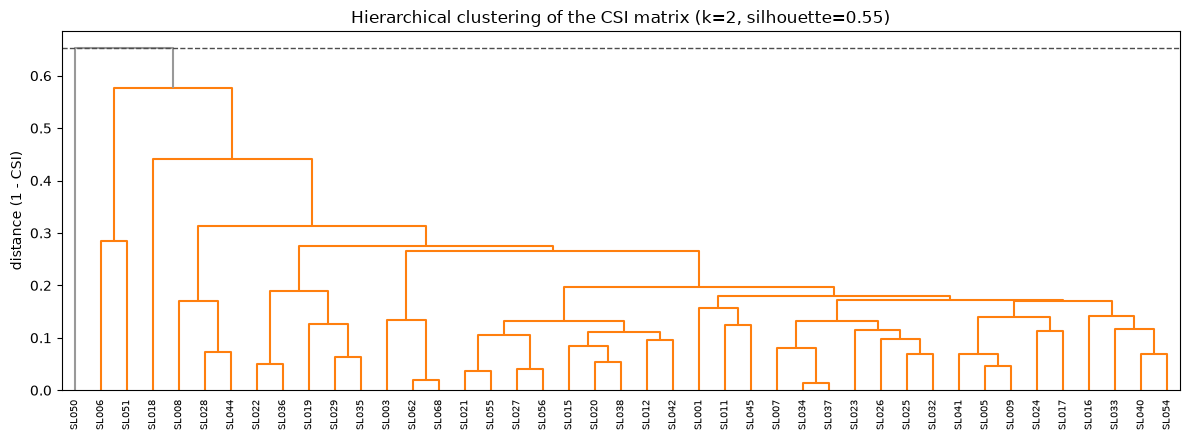

In [24]:
from scipy.cluster.hierarchy import linkage, fcluster, dendrogram
from scipy.spatial.distance import squareform
from sklearn.metrics import silhouette_score

csi_matrix_full = pd.read_csv(Tables / "csi_matrix.csv", index_col=0)
csi_matrix_full.index = csi_matrix_full.columns = [short_code(c) for c in csi_matrix_full.columns]

dist = 1 - csi_matrix_full.values
np.fill_diagonal(dist, 0)
# A few sensor pairs lack enough overlap for a CSI at all; filled with the
# mean of the pairs that ARE known so clustering can run.
mean_dist = np.nanmean(dist[~np.eye(len(dist), dtype=bool)])
dist = np.where(np.isnan(dist), mean_dist, dist)
np.fill_diagonal(dist, 0)

Z = linkage(squareform(dist, checks=False), method="average")
scores = {k: silhouette_score(dist, fcluster(Z, t=k, criterion="maxclust"), metric="precomputed")
         for k in range(2, 6)}
best_k = max(scores, key=scores.get)
print(f"silhouette by k: { {k: round(v,3) for k,v in scores.items()} }")
print(f"best: k={best_k}, silhouette={scores[best_k]:.3f} "
     f"(Byrne et al. 2024, Cork: k=2, silhouette=0.19)")

labels = fcluster(Z, t=best_k, criterion="maxclust")
sizes = pd.Series(labels).value_counts().sort_index()
print(f"cluster sizes: {sizes.to_dict()}")
if sizes.min() == 1:
    print("smallest cluster has one member -- a single extreme-CSI sensor "
         "isolated from the rest, not a genuine two-group partition; the "
         "apparent silhouette score is inflated by that isolation rather "
         "than reflecting real network structure.")

fig, ax = plt.subplots(figsize=(12, 4.5))
cut = np.sort(Z[:, 2])[-(best_k - 1)] - 1e-9 if best_k > 1 else 0
dendrogram(Z, labels=list(csi_matrix_full.index), ax=ax, color_threshold=cut,
          above_threshold_color="0.6", leaf_font_size=7)
ax.axhline(cut, color="0.3", ls="--", lw=1)
ax.set_ylabel("distance (1 - CSI)")
ax.set_title(f"Hierarchical clustering of the CSI matrix (k={best_k}, silhouette={scores[best_k]:.2f})")
plt.xticks(rotation=90)
fig.tight_layout()
fig.savefig(Figures / "08_csi_dendrogram.png", dpi=200, bbox_inches="tight")
plt.show()

## Part 5 — Combining the evidence

CSI, bias, the verdict, and the van Zoest flag rate are joined into one
table per candidate, then scored with Isolation Forest (scikit-learn): a
method that flags a point as unusual if it takes few random splits to
separate it from the rest of the data, using all three numeric signals at
once rather than one at a time. A sensor that is moderately unusual on
several signals together can rank higher here than on any single test
above — this is a ranking aid, not a verdict, and with 35 candidates and
three inputs it should not be read as more precise than that.

In [25]:
from sklearn.ensemble import IsolationForest

compare = out[["mean_csi", "bias_ref", "verdict"]].join(
    by_sensor[["pct_flagged"]], how="left")
compare = compare.rename(columns={"pct_flagged": "vanzoest_pct"})
compare["currently_reporting"] = ~compare.index.isin(not_reporting)

X = compare[["mean_csi", "bias_ref", "vanzoest_pct"]].copy()
X["bias_ref"] = X["bias_ref"].abs()
X = X.fillna(X.median())

iso = IsolationForest(n_estimators=200, contamination=0.15, random_state=0)
iso.fit(X)
compare["iso_unusual_score"] = (-iso.score_samples(X)).round(2)
compare = compare.sort_values("iso_unusual_score", ascending=False)
print(compare.round(2).head(15).to_string())

       mean_csi  bias_ref               verdict  vanzoest_pct  currently_reporting  iso_unusual_score
SL050      0.32     -2.63     calibration fault           5.7                 True               0.67
SL019      0.66      1.83  single-channel fault          16.3                False               0.67
SL051      0.32     -2.16          local source           4.4                 True               0.63
SL006      0.46      0.52            unresolved           2.3                False               0.56
SL018      0.54      1.68     calibration fault           1.0                False               0.54
SL037      0.85     -0.10  single-channel fault           0.9                 True               0.54
SL035      0.72      0.68  single-channel fault           9.6                False               0.52
SL045      0.72     -2.07            unresolved           0.4                False               0.52
SL012      0.78      1.15          local source          10.0                False

## Part 6 — Operational interpretation

Every sensor is assigned two independent fields: **current status**
(reporting or not, from Part 1) and **historical finding** (what the
diagnosis above found while it was reporting). Keeping them separate
matters — most offline sensors stopped reporting for reasons unrelated to
their PM2.5 behaviour, and collapsing the two into one label would imply
otherwise. Nothing is called "faulty" unless several independent tests
agree on it; a sensor flagged by only one check is reported as such.

In [26]:
def historical_finding(sensor):
    """What the diagnosis found while this sensor was reporting, independent
    of its current status."""
    if sensor not in daily.columns:
        return "insufficient historical data for a CSI-based assessment"
    if sensor in references:
        return "reference sensor (healthy standard, not diagnosed itself)"
    if sensor not in candidates:
        return "no strong evidence of abnormal behaviour"
    verdict = out.loc[sensor, "verdict"] if sensor in out.index else None
    iso = compare.loc[sensor, "iso_unusual_score"] if sensor in compare.index else np.nan
    if verdict == "local source":
        return "possible local source"
    if verdict in ("calibration fault", "single-channel fault", "frozen / hardware"):
        return verdict
    if verdict == "intermittent fault" or (pd.notna(iso) and iso > 0.55):
        return "worth a second look"
    return "unresolved"

full_index = sorted(paths.keys())
status = pd.DataFrame(index=full_index)
status["current_status"] = ["offline / not reporting" if c in not_reporting
                            else "currently reporting" for c in full_index]
status["historical_finding"] = [historical_finding(c) for c in full_index]

def operational_action(row):
    if row["current_status"] == "offline / not reporting":
        return f"offline -- requires attention (history: {row['historical_finding']})"
    hf = row["historical_finding"]
    if hf == "possible local source":
        return "possible local event -- report to Council, not a fault"
    if hf in ("calibration fault", "single-channel fault", "frozen / hardware"):
        return "requires investigation"
    if hf == "worth a second look":
        return "worth a second look"
    return "no strong evidence of abnormal behaviour"

status["operational_action"] = status.apply(operational_action, axis=1)

print("Current status:")
print(status["current_status"].value_counts().to_string())
print("\nHistorical finding:")
print(status["historical_finding"].value_counts().to_string())

Current status:
current_status
offline / not reporting    34
currently reporting        13

Historical finding:
historical_finding
single-channel fault                                         11
unresolved                                                   11
possible local source                                         5
worth a second look                                           5
no strong evidence of abnormal behaviour                      5
reference sensor (healthy standard, not diagnosed itself)     4
insufficient historical data for a CSI-based assessment       4
calibration fault                                             2


### Sensor status map

Every sensor is labelled, matching the style used for the CSI map in NB05
-- consistent labelling across the dissertation, and the codes stay
readable at this density without needing to hide any of them.

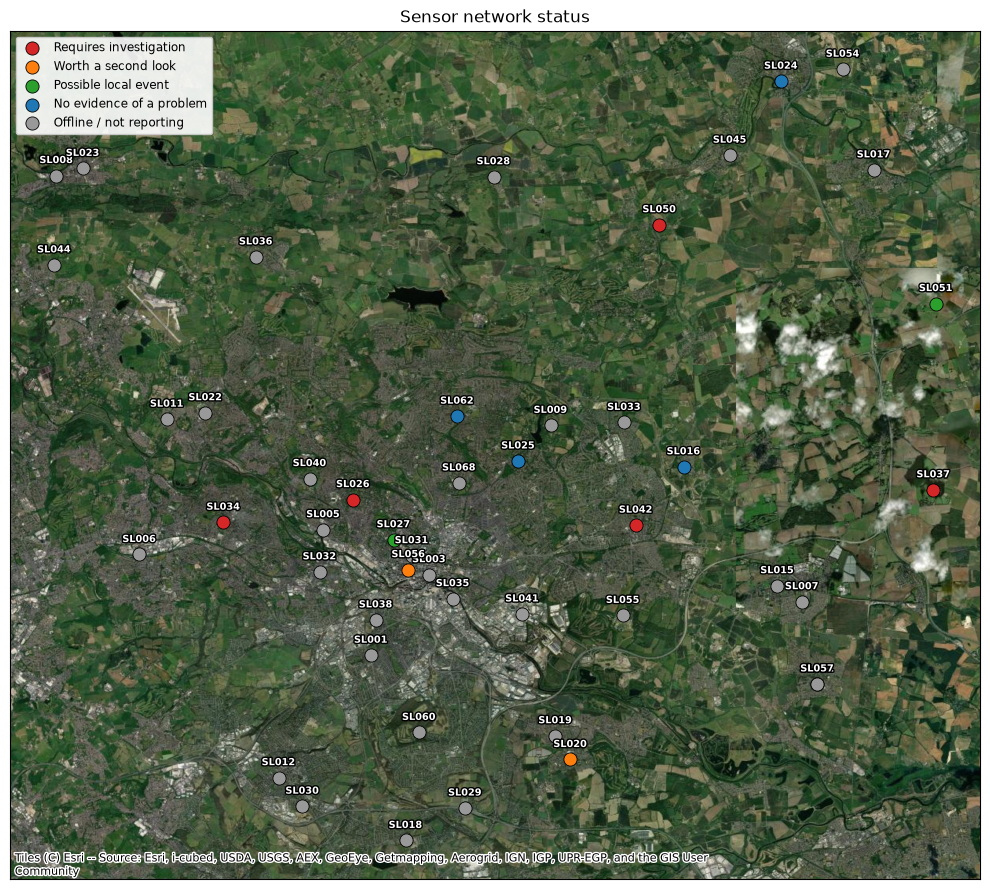

In [27]:
import contextily as cx
import pyproj
import matplotlib.patheffects as pe

transformer = pyproj.Transformer.from_crs("EPSG:4326", "EPSG:3857", always_xy=True)
map_x, map_y = transformer.transform(coords["lon"].to_numpy(), coords["lat"].to_numpy())
map_xy = pd.DataFrame({"x": map_x, "y": map_y}, index=coords.index)

order = ["requires investigation", "worth a second look",
        "possible local event -- report to Council, not a fault",
        "no strong evidence of abnormal behaviour", "offline / not reporting"]
colors = {"requires investigation": "tab:red", "worth a second look": "tab:orange",
         "possible local event -- report to Council, not a fault": "tab:green",
         "no strong evidence of abnormal behaviour": "tab:blue",
         "offline / not reporting": "0.6"}
labels = {"requires investigation": "Requires investigation",
         "worth a second look": "Worth a second look",
         "possible local event -- report to Council, not a fault": "Possible local event",
         "no strong evidence of abnormal behaviour": "No evidence of a problem",
         "offline / not reporting": "Offline / not reporting"}

cat = status["current_status"].where(status["current_status"] == "offline / not reporting",
                                     status["operational_action"])
plot_df = map_xy.join(cat.rename("cat"), how="inner")

fig, ax = plt.subplots(figsize=(10, 9))
for c in order:
    sub = plot_df[plot_df["cat"] == c]
    if sub.empty:
        continue
    ax.scatter(sub["x"], sub["y"], s=90, color=colors[c], edgecolor="k", lw=0.6,
              label=labels[c], zorder=3)
for code, row in plot_df.iterrows():
    ax.annotate(code, (row["x"], row["y"]), xytext=(0, 9), textcoords="offset points",
               fontsize=7, ha="center", fontweight="bold", color="white",
               path_effects=[pe.withStroke(linewidth=2, foreground="black")])

cx.add_basemap(ax, source=cx.providers.Esri.WorldImagery, zoom=12)
ax.legend(loc="upper left", fontsize=8.5, framealpha=0.9)
ax.set_xticks([]); ax.set_yticks([])
ax.set_title("Sensor network status")
fig.tight_layout()
fig.savefig(Figures / "08_status_map.png", dpi=200, bbox_inches="tight")
plt.show()

### Final summary table

In [28]:
coverage_pct = (100 * daily.notna().sum() / len(daily)).round(1)

summary = pd.DataFrame(index=sorted(paths.keys()))
summary["current_status"] = status["current_status"]
summary["coverage_pct"] = coverage_pct.reindex(summary.index)
summary["csi"] = rank["mean_csi"].reindex(summary.index).round(2)
summary["bias_ref"] = bias["bias_ref"].reindex(summary.index).round(2)
summary["historical_finding"] = status["historical_finding"]
summary["operational_action"] = status["operational_action"]
summary = summary.sort_values(["current_status", "operational_action"])
summary.to_csv(Tables / "nb08_final_summary.csv")
print(summary.to_string())

                current_status  coverage_pct   csi  bias_ref                                         historical_finding                                                                                  operational_action
SL016      currently reporting          69.7  0.75     -1.42                                                 unresolved                                                            no strong evidence of abnormal behaviour
SL024      currently reporting          86.4  0.73     -0.51                   no strong evidence of abnormal behaviour                                                            no strong evidence of abnormal behaviour
SL025      currently reporting          78.3  0.79     -0.85  reference sensor (healthy standard, not diagnosed itself)                                                            no strong evidence of abnormal behaviour
SL062      currently reporting          49.4  0.71     -1.10                                                 unresolved 

## Part 7 — Conclusion

The Leeds PM2.5 network can identify unusual concentration events and give
useful evidence that a currently reporting sensor may need investigation,
while separately identifying sensors that are offline.

For SL051 specifically, five independent tests agree: calibration
correction does not recover its CSI (Step 1); its implied fault size does
not match its measured calibration (Step 2); its evening excess is
seasonal, smooth, and seen by both channels (Steps 3-4); it is the only
candidate whose excess is not shared with any neighbour (Part 3); and it
shows an above-median rate on the independent van Zoest test (Part 3). This
combination is consistent with a genuine local source rather than an
instrument fault. SL050 and SL018 show the equivalent, opposite pattern for
calibration.

A CSI score alone is not a usable site-visit list, and no single test here
is trusted without the others agreeing. There is no confirmed real-world
site-visit record for any Leeds sensor to check these verdicts against —
only internal agreement between independent tests and a synthetic-network
validation with known planted faults, which the verdict rule recovered
correctly. Confidence is correspondingly higher for sensors where several
tests agree, and lower for the sensors left unresolved.